# Factors Associated With Math Performance Among Portuguese High-School Students

**Student:** Everett Ledbetter
**Course:** Data Anylitics  
**Date:** September 20, 2026  

**GitHub Repository:** [I will add the link after uploading my notebook to GitHub.]

## Dataset Source

This project uses the Student Performance dataset from the UCI Machine Learning Repository.
The data contain demographic, social, family, and school-related information for students at
Portuguese secondary schools.

This project uses the Mathematics course dataset, `student-mat.csv`.

Dataset link: https://archive.ics.uci.edu/dataset/320/student+performance

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [26]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Problem Statement

Student academic performance may be related to factors such as study time, attendance,
demographic characteristics, family background, and school-related support. This project
analyzes the UCI Student Performance Mathematics dataset to explore factors associated with
students' final mathematics grades.

The dataset contains 395 records for students in Portuguese secondary schools. It includes
demographic, social, family, school, and academic information. The final mathematics grade is
stored in the `G3` column and is measured on a scale from 0 to 20.

### Main Inquiry Question

What factors are associated with students' final mathematics grades?

### Sub-Questions

1. How does the average final mathematics grade differ by sex?
2. Is there a relationship between weekly study time and final mathematics grades?
3. How are school absences related to final mathematics grades?


In [27]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst five rows:")
display(df.head())

Number of rows: 395
Number of columns: 33

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data types:


,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object



First five rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Initial Data Exploration

The dataset contains 395 rows and 33 columns. Each row represents one student enrolled in a
mathematics course at a Portuguese secondary school. The dataset includes categorical variables,
such as sex, school, family support, and internet access. It also includes numerical variables,
such as age, study time, absences, and grades.

The primary outcome variable in this project is `G3`, which represents the student's final
mathematics grade. The `G3` values range from 0 to 20, with higher values representing better
academic performance.

# Data Cleaning

Before completing the analysis, I checked the dataset for missing values, duplicate records,
incorrect data types, inconsistent categorical values, and potential numeric outliers. I created
a separate copy of the dataset so that the original imported data would remain unchanged.

In [28]:
df_clean = df.copy()

missing_values = df_clean.isnull().sum()

print("Missing values in each column:")
display(missing_values)

print("\nTotal missing values in the dataset:", missing_values.sum())

print("Original dataset shape:", df.shape)
print("Working copy shape:", df_clean.shape)

Missing values in each column:


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0



Total missing values in the dataset: 0
Original dataset shape: (395, 33)
Working copy shape: (395, 33)


### Missing Values

I checked every column for missing values using the `isnull()` function. The dataset had no
missing values, so no records needed to be removed and no missing values needed to be replaced.

In [29]:
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Records

I checked the dataset for exact duplicate rows using the `duplicated()` function. The result
showed that there were 0 duplicate rows. Therefore, no records needed to be removed.

In [30]:
print("Data types for all columns:")
display(df_clean.dtypes)

Data types for all columns:


,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [31]:
numeric_columns = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health",
    "absences", "G1", "G2", "G3"
]

display(df_clean[numeric_columns].dtypes)

,0
age,int64
Medu,int64
Fedu,int64
traveltime,int64
studytime,int64
failures,int64
famrel,int64
freetime,int64
goout,int64
Dalc,int64


### Data Types

I reviewed the data type of every column. Numeric variables, including age, study time,
absences, and the three grade variables (`G1`, `G2`, and `G3`), were stored as integer values.
Categorical variables, including school, sex, address, family support, and internet access, were
stored as text (`object`) values.

The data types were appropriate for the planned analysis, so no data-type conversions were
required.

In [32]:
categorical_columns = df_clean.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df_clean[column].value_counts().sort_index())

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

--- school ---
school
GP    349
MS     46
Name: count, dtype: int64

--- sex ---
sex
F    208
M    187
Name: count, dtype: int64

--- address ---
address
R     88
U    307
Name: count, dtype: int64

--- famsize ---
famsize
GT3    281
LE3    114
Name: count, dtype: int64

--- Pstatus ---
Pstatus
A     41
T    354
Name: count, dtype: int64

--- Mjob ---
Mjob
at_home      59
health       34
other       141
services    103
teacher      58
Name: count, dtype: int64

--- Fjob ---
Fjob
at_home      20
health       18
other       217
services    111
teacher      29
Name: count, dtype: int64

--- reason ---
reason
course        145
home          109
other          36
reputation    105
Name: count, dtype: int64

--- guardian ---
guardian
father     90
mother    273
other      32
Name: count, dtype:

In [33]:
for column in categorical_columns:
    df_clean[column] = df_clean[column].str.strip().str.lower()

print("Sex categories after standardization:")
print(df_clean["sex"].value_counts())

Sex categories after standardization:
sex
f    208
m    187
Name: count, dtype: int64


### Categorical Variables

I reviewed the unique values in all categorical columns to check for inconsistent spelling,
capitalization, and spacing. The categories were consistent. As an additional cleaning step,
I removed possible extra spaces and converted all text values to lowercase. This ensures that
categories with different capitalization or spacing would not be treated as separate groups
during analysis.

### Numeric Outliers

I checked the `absences` variable for potential outliers because unusually high absence counts
could affect the analysis of attendance and final mathematics grades. I used the interquartile
range (IQR) method to identify values that were much higher or lower than most observations.

In [34]:
Q1 = df_clean["absences"].quantile(0.25)
Q3 = df_clean["absences"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

absence_outliers = df_clean[
    (df_clean["absences"] < lower_bound) |
    (df_clean["absences"] > upper_bound)
]

print("\nNumber of potential absence outliers:", len(absence_outliers))

display(
    absence_outliers[["absences", "G3"]]
    .sort_values("absences", ascending=False)
    .head(10)
)

Q1: 0.0
Q3: 8.0
IQR: 8.0
Lower bound: -12.0
Upper bound: 20.0

Number of potential absence outliers: 15


,absences,G3
276,75,9
183,56,8
74,54,11
315,40,11
307,38,8
280,30,8
205,28,9
103,26,6
40,25,11
198,24,18


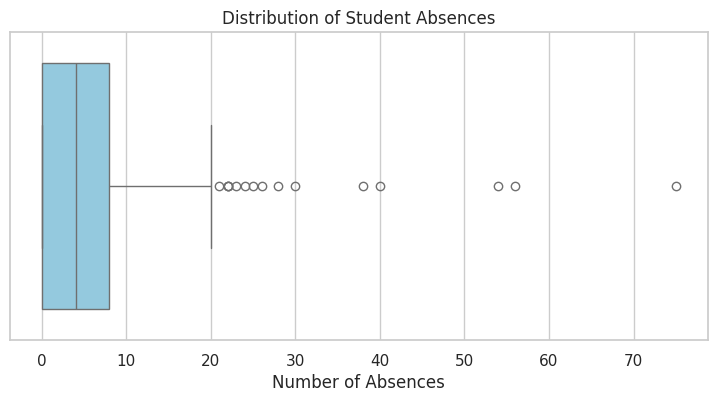

In [35]:
plt.figure(figsize=(9, 4))

sns.boxplot(x=df_clean["absences"], color="skyblue")

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.show()

The IQR method identified some potential high-absence outliers. I reviewed these values and
decided to retain them because a high number of school absences is realistic and may be meaningful
to the research question. There was no evidence that these values were impossible or obvious
data-entry errors. Removing them could hide an important pattern between attendance and final
mathematics grades.

# Exploratory Data Analysis and Interpretation

## Question A: How does the average final mathematics grade differ by sex?

This analysis compares the average final mathematics grade (`G3`) for female and male students.

In [36]:
sex_grade_summary = (
    df_clean.groupby("sex")["G3"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
display(sex_grade_summary)

,count,mean,median,std
sex,,,,
f,208,9.97,10.0,4.62
m,187,10.91,11.0,4.50


/tmp/ipykernel_1525/3895095424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


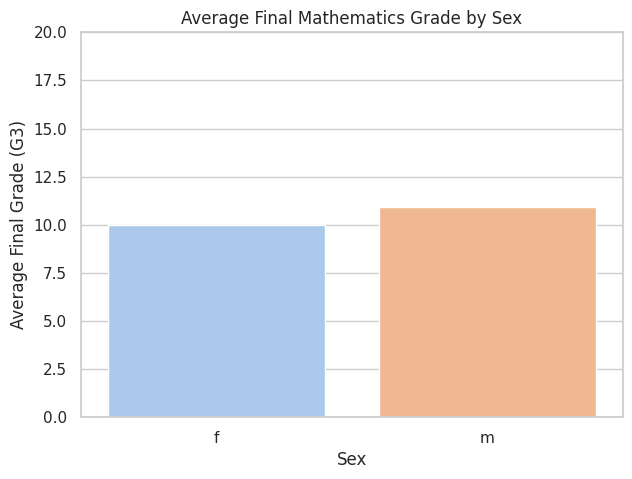

In [37]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="sex",
    y="G3",
    errorbar=None,
    palette="pastel"
)

plt.title("Average Final Mathematics Grade by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Final Grade (G3)")
plt.ylim(0, 20)

plt.show()

The analysis compared average final mathematics grades by sex. Female students had an average
final grade of approximately 10, while male students had an average final grade of approximately
11 out of 20.

Male students had a slightly higher average final mathematics grade in this dataset. However,
the difference was small. This result shows an association in this sample, but it does not prove
that sex caused the difference in final grades. Other factors, such as study time, previous
academic performance, attendance, and family support, may also influence student performance.

## Question B: Is there a relationship between weekly study time and final mathematics grades?

The `studytime` variable represents students' weekly study-time category:

- `1` = Less than 2 hours per week
- `2` = 2 to 5 hours per week
- `3` = 5 to 10 hours per week
- `4` = More than 10 hours per week

This analysis compares average final mathematics grades across the four study-time categories.

In [38]:
studytime_labels = {
    1: "Less than 2 hours",
    2: "2 to 5 hours",
    3: "5 to 10 hours",
    4: "More than 10 hours"
}

df_clean["studytime_label"] = df_clean["studytime"].map(studytime_labels)

display(
    df_clean[["studytime", "studytime_label", "G3"]].head()
)

,studytime,studytime_label,G3
0,2,2 to 5 hours,6
1,2,2 to 5 hours,6
2,2,2 to 5 hours,10
3,3,5 to 10 hours,15
4,2,2 to 5 hours,10


In [39]:
studytime_summary = (
    df_clean.groupby(["studytime", "studytime_label"])["G3"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .sort_values("studytime")
    .round(2)
)

display(studytime_summary)

,studytime,studytime_label,count,mean,median,std
0,1,Less than 2 hours,105,10.05,10.0,4.96
1,2,2 to 5 hours,198,10.17,11.0,4.22
2,3,5 to 10 hours,65,11.40,12.0,4.64
3,4,More than 10 hours,27,11.26,12.0,5.28


/tmp/ipykernel_1525/49725257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


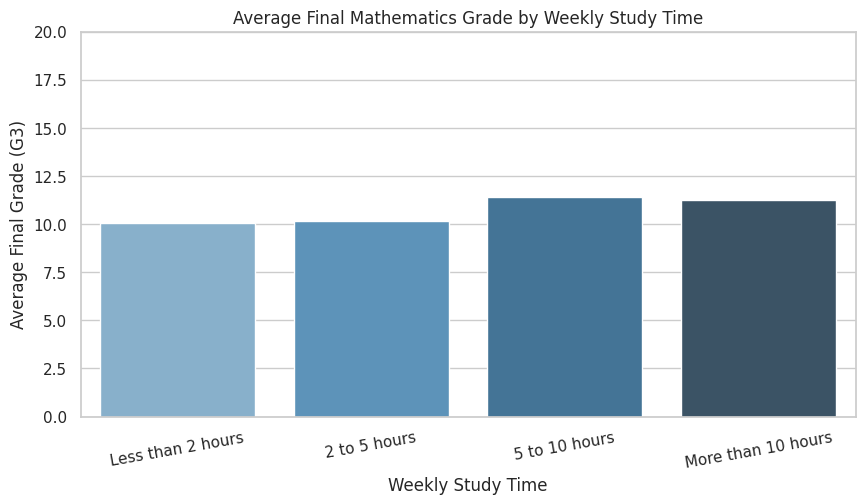

In [40]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_clean,
    x="studytime_label",
    y="G3",
    order=[
        "Less than 2 hours",
        "2 to 5 hours",
        "5 to 10 hours",
        "More than 10 hours"
    ],
    errorbar=None,
    palette="Blues_d"
)

plt.title("Average Final Mathematics Grade by Weekly Study Time")
plt.xlabel("Weekly Study Time")
plt.ylabel("Average Final Grade (G3)")
plt.ylim(0, 20)
plt.xticks(rotation=10)

plt.show()

### Interpretation of Question B

The analysis compared average final mathematics grades across four weekly study-time categories.
Students who studied less than 2 hours per week had an average final grade of approximately 10.
Students who studied 2 to 5 hours per week also had an average final grade of approximately 10.
Students who studied 5 to 10 hours per week had an average final grade of approximately 11, and
students who studied more than 10 hours per week also had an average final grade of approximately 11.

Overall, the results suggest a small positive relationship between study time and final mathematics
grades. Students in the higher study-time categories had slightly higher average grades than students
in the lower study-time categories. However, the difference was small, so study time alone may not
fully explain academic performance. Other factors, including absences, prior grades, motivation,
and family support, may also influence final mathematics grades.

## Question C: How are school absences related to final mathematics grades?

This analysis examines whether students with different numbers of school absences had different
average final mathematics grades. Students are grouped by absence count to make the comparison
easier to interpret.

In [41]:
absence_bins = [-1, 0, 5, 10, df_clean["absences"].max()]

absence_labels = [
    "0 absences",
    "1–5 absences",
    "6–10 absences",
    "More than 10 absences"
]

df_clean["absence_group"] = pd.cut(
    df_clean["absences"],
    bins=absence_bins,
    labels=absence_labels
)

display(df_clean[["absences", "absence_group", "G3"]].head(10))

,absences,absence_group,G3
0,6,6–10 absences,6
1,4,1–5 absences,6
2,10,6–10 absences,10
3,2,1–5 absences,15
4,4,1–5 absences,10
5,10,6–10 absences,15
6,0,0 absences,11
7,6,6–10 absences,6
8,0,0 absences,19
9,0,0 absences,15


In [42]:
absence_summary = (
    df_clean.groupby("absence_group", observed=False)["G3"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

display(absence_summary)

,count,mean,median,std
absence_group,,,,
0 absences,115,8.44,10.0,6.47
1–5 absences,134,11.65,11.0,3.11
6–10 absences,80,11.40,11.0,3.23
More than 10 absences,66,10.15,10.0,3.18


/tmp/ipykernel_1525/2139723008.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


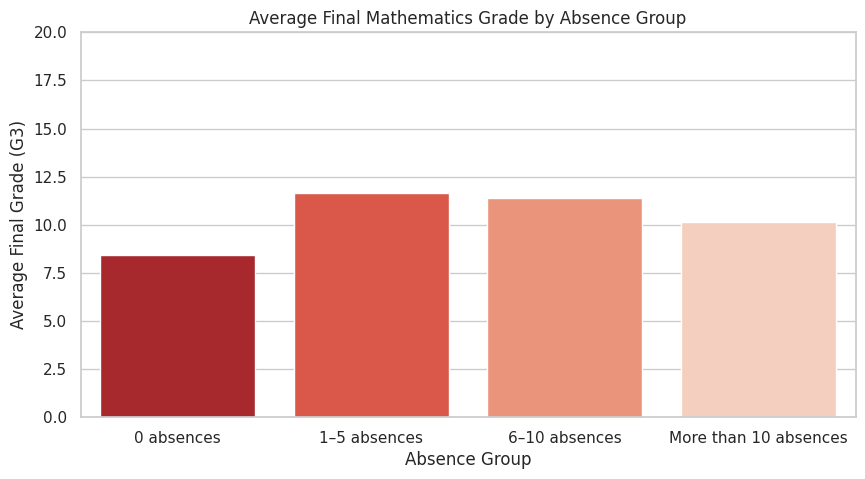

In [43]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_clean,
    x="absence_group",
    y="G3",
    order=absence_labels,
    errorbar=None,
    palette="Reds_r"
)

plt.title("Average Final Mathematics Grade by Absence Group")
plt.xlabel("Absence Group")
plt.ylabel("Average Final Grade (G3)")
plt.ylim(0, 20)

plt.show()

Correlation between absences and final grade: 0.034


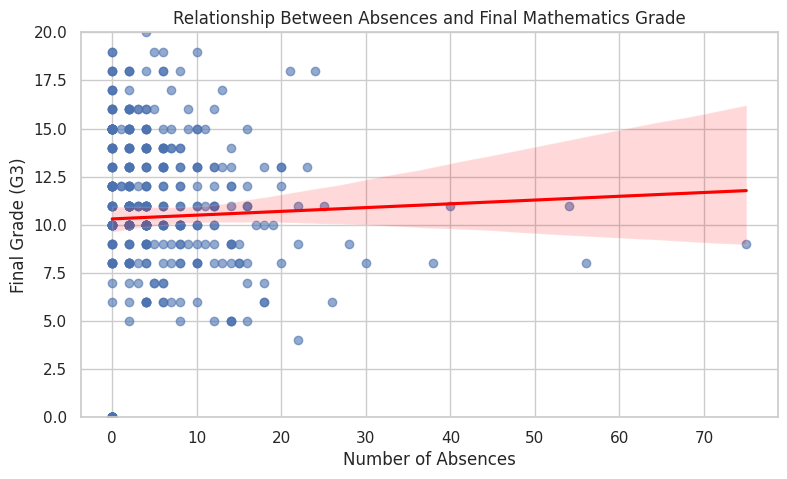

In [44]:
correlation = df_clean["absences"].corr(df_clean["G3"])

print("Correlation between absences and final grade:", round(correlation, 3))

plt.figure(figsize=(9, 5))

sns.regplot(
    data=df_clean,
    x="absences",
    y="G3",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Relationship Between Absences and Final Mathematics Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.ylim(0, 20)

plt.show()

In [45]:
correlation = df_clean["absences"].corr(df_clean["G3"])

print("Correlation between absences and final grade:", round(correlation, 3))

Correlation between absences and final grade: 0.034


### Interpretation of Question C

The analysis compared average final mathematics grades across four absence groups. Students with
0 absences had an average final grade of approximately 8. Students with 1–5 absences had the
highest average final grade of approximately 12. Students with 6–10 absences had an average final
grade of approximately 11, while students with more than 10 absences had an average final grade
of approximately 10.

The absence-group averages did not show a simple linear pattern. In this dataset, students with
1–5 absences performed better on average than students with no absences or students with more
than 10 absences. The correlation between absences and final grade was 0.034, which indicates
little to no linear relationship.

These results show an association in this sample, not causation. Absences may be related to other
factors, such as student health, academic ability, motivation, or outside responsibilities.
Therefore, this analysis cannot conclude that absences alone caused differences in final
mathematics grades.

# Summary

This project examined factors associated with final mathematics grades among Portuguese
high-school students using the UCI Student Performance Mathematics dataset. The dataset contained
395 student records and included demographic, family, social, school, and academic variables.

The first analysis compared final mathematics grades by sex. Female students had an average final
grade of approximately 10, while male students had an average final grade of approximately 11.
Male students had a slightly higher average grade in this dataset, but the difference was small.

The second analysis examined weekly study time. Students who studied less than 2 hours per week
and 2–5 hours per week had average final grades of approximately 10. Students who studied 5–10
hours per week and more than 10 hours per week had average final grades of approximately 11.
This suggests a small positive relationship between study time and final mathematics grades.

The third analysis examined absences. The results did not show a simple pattern in which more
absences always resulted in lower grades. Students with 1–5 absences had the highest average
final grade, while students with no absences had the lowest average final grade. The correlation
between absences and final grade was 0.034, indicating little to no linear relationship.

One limitation of this project is that the analysis identifies associations, not causes. The
dataset cannot determine whether study time, sex, or absences directly caused changes in student
performance. Future research could examine multiple variables at the same time, including prior
grades (`G1` and `G2`), previous failures, family support, school support, and internet access.
A multiple-regression analysis could provide a more complete understanding of factors related to
final mathematics grades.